# **Лабораторная работа №2: Обнаружение аномалий и выбросов в данных**

##**1. Загрузка и профилирование данных**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('/content/data/health_fitness_dataset.csv')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 687701 строк, 23 столбцов


,participant_id,date,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
0,1,2024/1/1,56,F,165.3,50.55,18.50,Dancing,42.1,Low,...,69.5,110.7,72.9,5.37,6.6,4,1.5,Never,NaN,0.04
1,1,2024/1/4,56,F,165.3,55.38,20.27,Swimming,66.9,Low,...,69.5,110.7,72.9,5.39,8.1,3,1.8,Never,NaN,0.07
2,1,2024/1/5,56,F,165.3,56.49,20.68,Swimming,20.0,Medium,...,69.5,110.7,72.9,5.42,6.2,5,2.7,Never,NaN,0.09
3,1,2024/1/7,56,F,165.3,52.23,19.12,Weight Training,23.5,Medium,...,69.5,110.7,72.9,5.44,7.2,4,2.6,Never,NaN,0.21
4,1,2024/1/9,56,F,165.3,53.96,19.75,Swimming,75.0,Medium,...,69.5,110.7,72.9,5.47,7.1,7,1.5,Never,NaN,0.33


In [2]:
print("Информация о столбцах и типах")
df.info()

print("\nСтатистика по числовым признакам")
df.describe()


Информация о столбцах и типах
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  object 
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  object 
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   bmi                       687701 non-null  float64
 7   activity_type             687701 non-null  object 
 8   duration_minutes          687701 non-null  float64
 9   intensity                 687701 non-null  object 
 10  calories_burned           687701 non-null  float64
 11  daily_steps               687701 non-null  int64  
 12  avg_heart_rate            687701 non-null  int64  
 13  resting_heart_

,participant_id,age,height_cm,weight_kg,bmi,duration_minutes,calories_burned,daily_steps,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,61.728155,21.663562,74.026662,15.381302,8628.370918,131.454165,70.010547,120.001260,80.188079,9.492198,7.048799,5.472029,2.499427,9.524900
std,865.997215,13.581770,9.140811,8.547730,1.939251,35.095472,9.985552,2054.756608,17.814744,5.074563,10.008917,8.239418,2.246180,0.972068,1.914969,0.579050,5.502485
min,1.000000,18.000000,145.000000,39.760000,18.500000,20.000000,0.800000,-419.000000,82.000000,51.100000,78.000000,53.700000,4.530000,4.000000,1.000000,1.500000,0.020000
25%,749.000000,30.000000,161.700000,55.500000,20.060000,46.300000,7.800000,7203.000000,118.000000,66.500000,113.100000,74.600000,7.820000,6.400000,4.000000,2.000000,4.770000
50%,1499.000000,42.000000,168.200000,61.060000,21.640000,72.800000,13.000000,8607.000000,130.000000,70.000000,120.200000,80.100000,9.460000,7.000000,5.000000,2.500000,9.510000
75%,2249.000000,53.000000,175.300000,67.310000,23.270000,99.500000,20.700000,10027.000000,144.000000,73.500000,127.000000,85.700000,11.050000,7.700000,7.000000,3.000000,14.230000
max,3000.000000,64.000000,198.500000,98.110000,24.900000,152.100000,92.000000,17241.000000,206.000000,87.100000,152.700000,112.100000,18.840000,10.000000,10.000000,3.500000,21.930000


In [3]:
print("\nПропуски в данных:")
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

print(missing)

print("\nАнализ наиболее проблемных столбцов:")
missing[missing['Пропуски'] > 0]


Пропуски в данных:
                          Пропуски  Доля (%)
health_condition            490275     71.29
date                             0      0.00
participant_id                   0      0.00
gender                           0      0.00
height_cm                        0      0.00
weight_kg                        0      0.00
age                              0      0.00
bmi                              0      0.00
activity_type                    0      0.00
intensity                        0      0.00
duration_minutes                 0      0.00
daily_steps                      0      0.00
avg_heart_rate                   0      0.00
resting_heart_rate               0      0.00
calories_burned                  0      0.00
blood_pressure_systolic          0      0.00
blood_pressure_diastolic         0      0.00
sleep_hours                      0      0.00
endurance_level                  0      0.00
stress_level                     0      0.00
hydration_level                  0 

,Пропуски,Доля (%)
health_condition,490275,71.29



Анализ диапазонов значений и экстремальных значений:

Столбец 'participant_id':
  Минимум: 1
  Максимум: 3000
  Среднее: 1499.78
  Медиана: 1499.00
  Выбросов (по методу IQR): 0

Столбец 'age':
  Минимум: 18
  Максимум: 64
  Среднее: 41.66
  Медиана: 42.00
  Выбросов (по методу IQR): 0

Столбец 'height_cm':
  Минимум: 145.0
  Максимум: 198.5
  Среднее: 168.59
  Медиана: 168.20
  Выбросов (по методу IQR): 460

Столбец 'weight_kg':
  Минимум: 39.76
  Максимум: 98.11
  Среднее: 61.73
  Медиана: 61.06
  Выбросов (по методу IQR): 3969

Столбец 'bmi':
  Минимум: 18.5
  Максимум: 24.9
  Среднее: 21.66
  Медиана: 21.64
  Выбросов (по методу IQR): 0

Столбец 'duration_minutes':
  Минимум: 20.0
  Максимум: 152.1
  Среднее: 74.03
  Медиана: 72.80
  Выбросов (по методу IQR): 0

Столбец 'calories_burned':
  Минимум: 0.8
  Максимум: 92.0
  Среднее: 15.38
  Медиана: 13.00
  Выбросов (по методу IQR): 17441

Столбец 'daily_steps':
  Минимум: -419
  Максимум: 17241
  Среднее: 8628.37
  Медиана: 8607.00

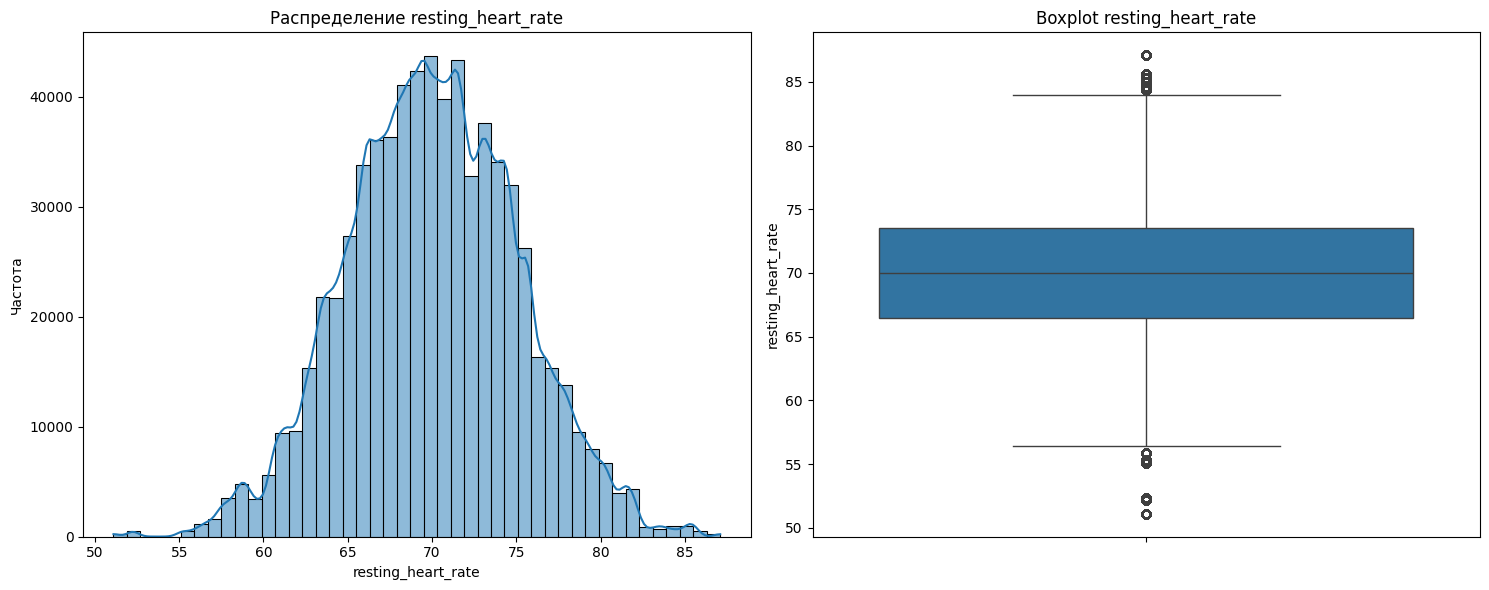


Статистика для resting_heart_rate:
Нижняя граница нормальных значений (IQR): 56.0
Верхняя граница нормальных значений (IQR): 84.0
Количество выбросов: 3738 (0.54%)
Минимальное значение в выбросах: 51.1
Максимальное значение в выбросах: 87.1
Асимметрия: 0.00833
Распределение близко к симметричному.


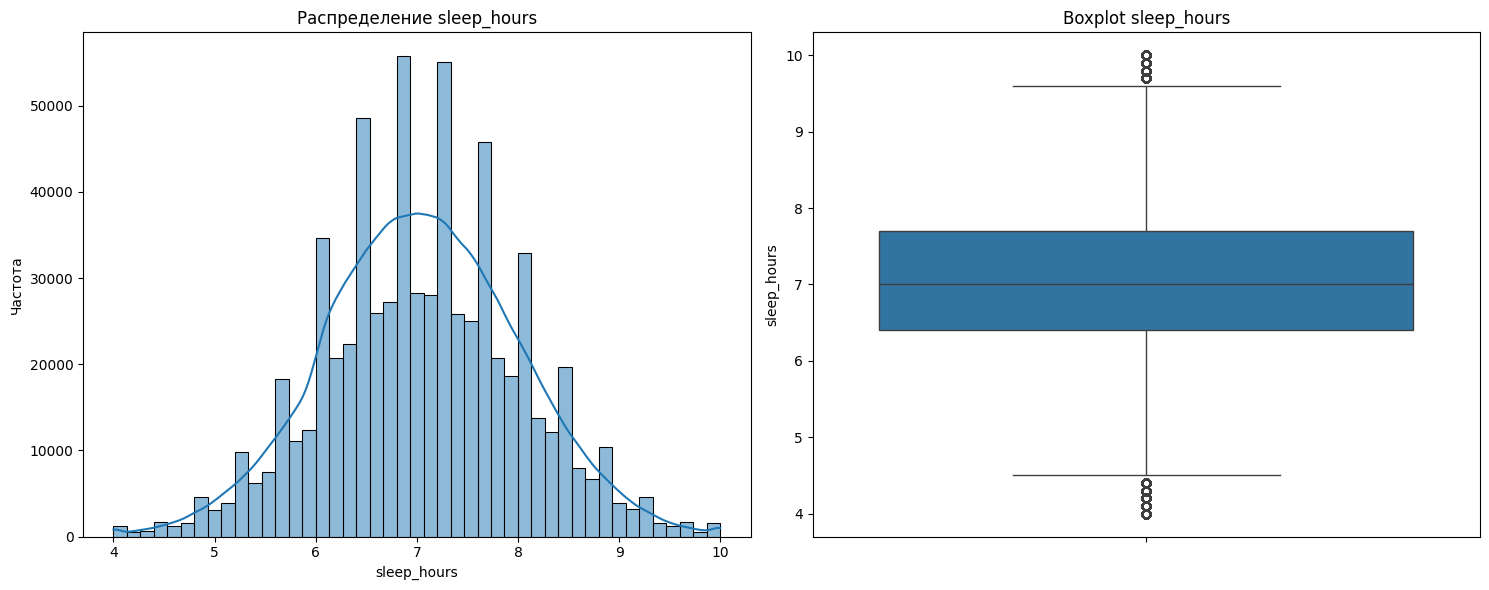


Статистика для sleep_hours:
Нижняя граница нормальных значений (IQR): 4.5
Верхняя граница нормальных значений (IQR): 9.7
Количество выбросов: 5897 (0.86%)
Минимальное значение в выбросах: 4.0
Максимальное значение в выбросах: 10.0
Асимметрия: 0.00785
Распределение близко к симметричному.


In [4]:
print("\nАнализ диапазонов значений и экстремальных значений:")
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    print(f"\nСтолбец '{col}':")
    print(f"  Минимум: {df[col].min()}")
    print(f"  Максимум: {df[col].max()}")
    print(f"  Среднее: {df[col].mean():.2f}")
    print(f"  Медиана: {df[col].median():.2f}")
    # Проверка на аномально большие/маленькие значения относительно IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  Выбросов (по методу IQR): {len(outliers)}")


# Визуальный анализ для выбранных числовых признаков: resting_heart_rate и sleep_hours
selected_columns = ['resting_heart_rate', 'sleep_hours']
for column in selected_columns:
    if column in df.columns:
     # Пересчитываем выбросы для текущего столбца
      Q1 = df[column].quantile(0.25)
      Q3 = df[column].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

      plt.figure(figsize=(15, 6))
      #KDE
      plt.subplot(1, 2, 1)
      sns.histplot(df[column], kde=True, bins=45)
      plt.title(f'Распределение {column}')
      plt.xlabel(column)
      plt.ylabel('Частота')

      # Boxplot
      plt.subplot(1, 2, 2)
      sns.boxplot(y=df[column])
      plt.title(f'Boxplot {column}')
      plt.ylabel(column)
      plt.tight_layout()
      plt.show()

      print(f"\nСтатистика для {column}:")
      print(f"Нижняя граница нормальных значений (IQR): {lower_bound:.1f}")
      print(f"Верхняя граница нормальных значений (IQR): {upper_bound:.1f}")
      print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
      if len(outliers) > 0:
          print(f"Минимальное значение в выбросах: {outliers[column].min():.1f}")
          print(f"Максимальное значение в выбросах: {outliers[column].max():.1f}")
      else:
          print("Выбросов не обнаружено.")
      print(f"Асимметрия: {df[column].skew():.5f}")
      if abs(df[column].skew()) > 1:
          print("Распределение асимметрично (скошено).")
      else:
          print("Распределение близко к симметричному.")

В обоих признаках выбросы не являются критическими — значения не выходят за реалистичные границы. Доля выбросов невелика (менее 1%), что позволяет оставить их в выборке без дополнительной обработки.

##**2. Проверка нормальности распределения**


Описательная статистика для 'resting_heart_rate':
Среднее: 70.01
Медиана: 70.00
Стандартное отклонение: 5.07
Коэффициент асимметрии: 0.00833
Коэффициент эксцесса: -0.01698

Описательная статистика для 'sleep_hours':
Среднее: 7.05
Медиана: 7.00
Стандартное отклонение: 0.97
Коэффициент асимметрии: 0.00785
Коэффициент эксцесса: 0.01061


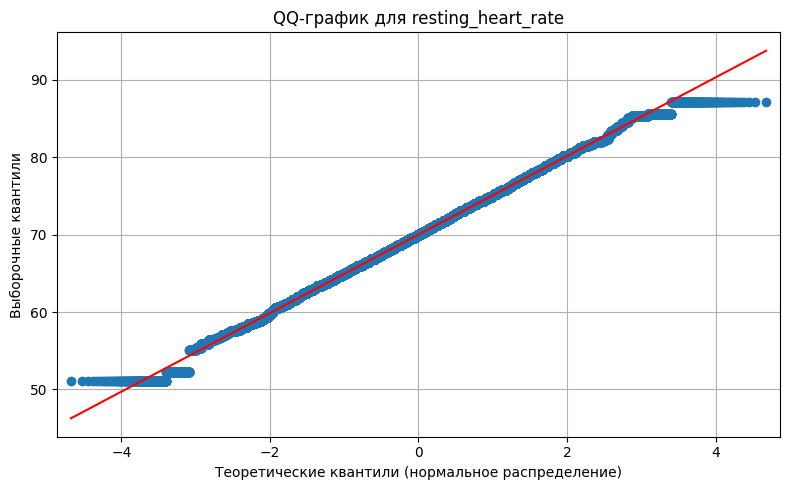

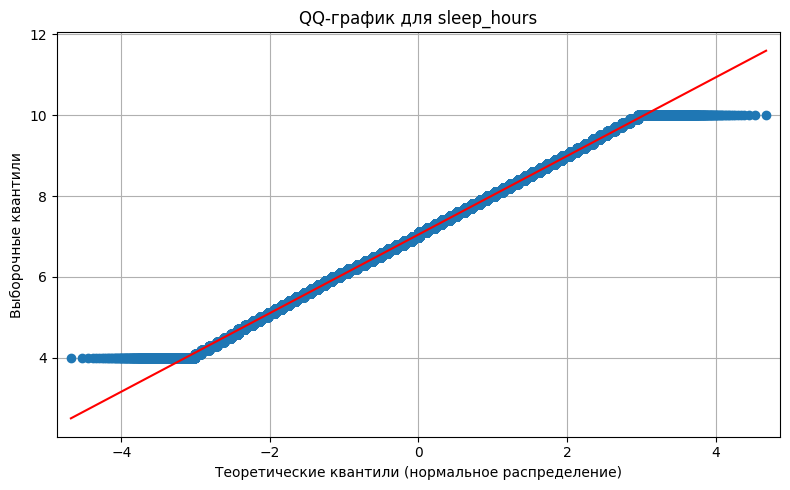


Критерий Шапиро–Уилка для 'resting_heart_rate':
Статистика теста (W): 0.99956
p-значение: 0.00000
Уровень значимости (α): 0.05
Вывод: H0 отклоняется — данные не распределены нормально (на уровне значимости α = 0.05).

Критерий Шапиро–Уилка для 'sleep_hours':
Статистика теста (W): 0.99862
p-значение: 0.00000
Уровень значимости (α): 0.05
Вывод: H0 отклоняется — данные не распределены нормально (на уровне значимости α = 0.05).


In [8]:
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", message="scipy.stats.shapiro: For N > 5000")

# 1. Вычисление описательных характеристик
selected_columns = ['resting_heart_rate', 'sleep_hours']

for column in selected_columns:
    if column in df.columns:
        print(f"\nОписательная статистика для '{column}':")
        print(f"Среднее: {df[column].mean():.2f}")
        print(f"Медиана: {df[column].median():.2f}")
        print(f"Стандартное отклонение: {df[column].std():.2f}")
        print(f"Коэффициент асимметрии: {df[column].skew():.5f}")
        print(f"Коэффициент эксцесса: {df[column].kurtosis():.5f}")
    else:
        print(f"Столбец '{column}' не найден в датасете.")

# 2. Графический анализ (QQ-график и сравнение с нормальным распределением)
for column in selected_columns:
    if column in df.columns:
        # QQ‑график
        fig, ax = plt.subplots(figsize=(8, 5))
        sm.qqplot(df[column], line='s', ax=ax)  # Явно передаём оси (ax) в функцию
        ax.set_title(f'QQ‑график для {column}')
        ax.set_xlabel('Теоретические квантили (нормальное распределение)')
        ax.set_ylabel('Выборочные квантили')
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Столбец '{column}' не найден в датасете — пропуск визуализации.")

# 3. Проверка нормальности распределения по критерию Шапиро–Уилка
alpha = 0.05  # Уровень значимости

for column in selected_columns:
    if column in df.columns:
        stat, p_value = stats.shapiro(df[column])
        print(f"\nКритерий Шапиро–Уилка для '{column}':")
        print(f"Статистика теста (W): {stat:.5f}") #чем ближе к 1, тем ближе к норм распр
        print(f"p-значение: {p_value:.5f}")  #вер-ть получить такие данные, если норм распр верно
        print(f"Уровень значимости (α): {alpha}")
        # Формулировка гипотез:
        # H0: выборка подчиняется нормальному распределению
        # H1: выборка не подчиняется нормальному распределению

        if p_value > alpha:
            print("Вывод: H0 не отклоняется — данные распределены нормально (на уровне значимости α = 0.05).")
        else:
            print("Вывод: H0 отклоняется — данные не распределены нормально (на уровне значимости α = 0.05).")
    else:
        print(f"Столбец '{column}' не найден в датасете — тест не проведён.")


##**3. Обнаружение выбросов статистическими методами**

Анализ выбросов для 'resting_heart_rate'

Метод Z-score (|Z| > 3):
Количество выбросов: 2117
Доля выбросов: 0.31%


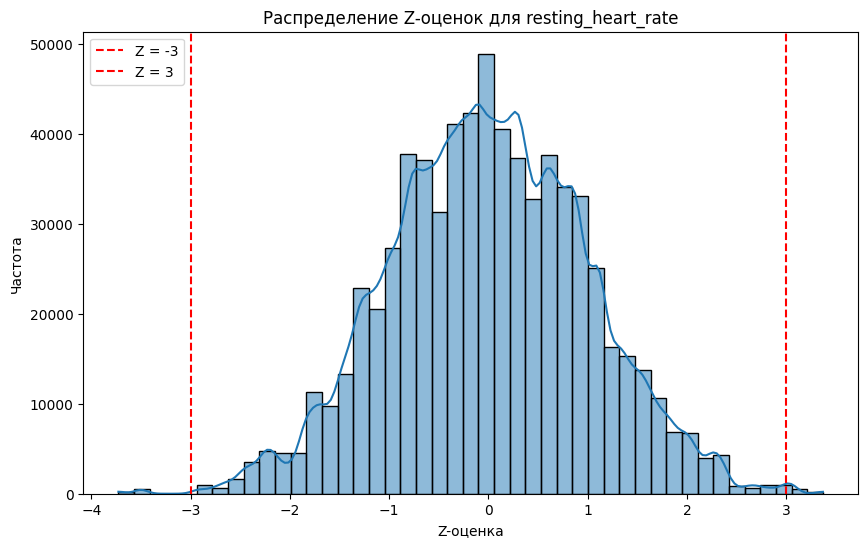


Метод IQR:
Q1: 66.50, Q3: 73.50, IQR: 7.00
Границы: [56.00, 84.00]
Количество выбросов: 3738
Доля выбросов: 0.54%


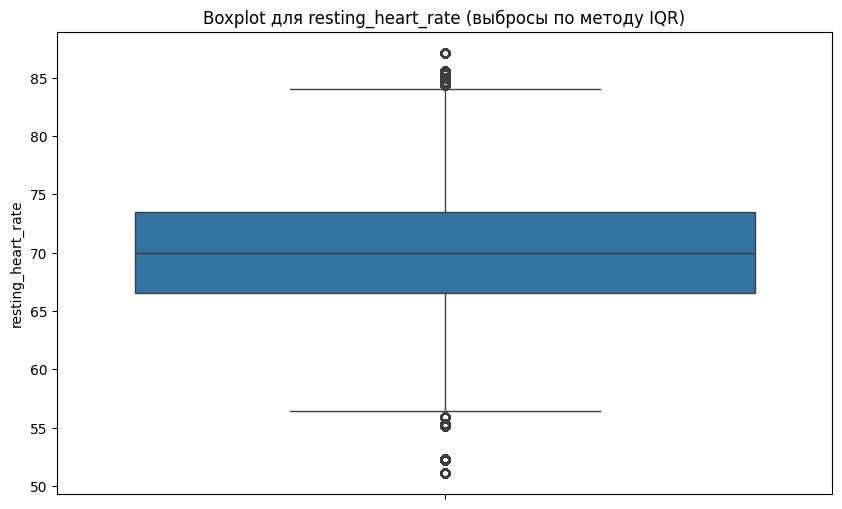


Сравнительный анализ методов:
Z-score: 2117 выбросов (0.31%)
IQR: 3738 выбросов (0.54%)
Метод IQR выявил больше выбросов — он менее чувствителен к форме распределения и лучше работает с «тяжёлыми хвостами».

Выбросы, обнаруженные обоими методами: 2117
Только Z-score: 0
Только IQR: 1621


In [9]:
column = 'resting_heart_rate'

print(f"Анализ выбросов для '{column}'\n")

# 1. Метод Z-score
# Шаг 1: Рассчитываем Z-оценки (отклонения от среднего в единицах стандартного отклонения)
mean = df[column].mean()
std = df[column].std()
z_scores = (df[column] - mean) / std

# Шаг 2: Определяем выбросы как значения с |Z| > 3
outliers_z = df[np.abs(z_scores) > 3]
z_outlier_count = len(outliers_z)

print(f"Метод Z-score (|Z| > 3):")
print(f"Количество выбросов: {z_outlier_count}")
print(f"Доля выбросов: {z_outlier_count / len(df) * 100:.2f}%")

# Шаг 3: Визуализация Z-оценок с выделением выбросов
plt.figure(figsize=(10, 6))
sns.histplot(z_scores, kde=True, bins=45)
plt.axvline(x=-3, color='red', linestyle='--', label='Z = -3')
plt.axvline(x=3, color='red', linestyle='--', label='Z = 3')
plt.title(f'Распределение Z-оценок для {column}')
plt.xlabel('Z-оценка')
plt.ylabel('Частота')
plt.legend()
plt.show()

# 2. Метод IQR
# Шаг 1: Вычисляем квартили и IQR (интерквартильный размах)
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

# Шаг 2: Определяем границы «нормальных» значений
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nМетод IQR:")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Шаг 3: Находим выбросы
outliers_iqr = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
iqr_outlier_count = len(outliers_iqr)
print(f"Количество выбросов: {iqr_outlier_count}")
print(f"Доля выбросов: {iqr_outlier_count / len(df) * 100:.2f}%")

plt.figure(figsize=(10, 6))
sns.boxplot(y=df[column])
plt.title(f'Boxplot для {column} (выбросы по методу IQR)')
plt.ylabel(column)
plt.show()

# 3. Сравнительный анализ методов
print(f"\nСравнительный анализ методов:")
print(f"Z-score: {z_outlier_count} выбросов ({z_outlier_count / len(df) * 100:.2f}%)")
print(f"IQR: {iqr_outlier_count} выбросов ({iqr_outlier_count / len(df) * 100:.2f}%)")

if z_outlier_count > iqr_outlier_count:
    print("Метод Z-score выявил больше выбросов — он более чувствителен к отклонениям от нормального распределения.")
elif z_outlier_count < iqr_outlier_count:
    print("Метод IQR выявил больше выбросов — он менее чувствителен к форме распределения и лучше работает с «тяжёлыми хвостами».")
else:
    print("Оба метода дали одинаковое количество выбросов.")

# Проверяем пересечение наборов выбросов
common_outliers = outliers_z[outliers_z.index.isin(outliers_iqr.index)]
print(f"\nВыбросы, обнаруженные обоими методами: {len(common_outliers)}")
print(f"Только Z-score: {z_outlier_count - len(common_outliers)}")
print(f"Только IQR: {iqr_outlier_count - len(common_outliers)}")


Так как распределение близко к нормальному - ассиметрия=0.00833, то метод Z-score более теоретически обоснован. Но для надёжности лучше использовать оба метода и анализировать пересечение - те значения, которые оба метода считают выбросами.

##**4. Метод локальной плотности**


   Анализ с использованием EUCLIDEAN расстояний

Анализ для k = 5
Статистика для k=5, метрика=euclidean:
  Среднее расстояние до 5 соседей: 0.0000 ± 0.0002
  Минимум/максимум: 0.0000 / 0.0154
  Порог аномальности (верхние 5 %): 0.0000
  Количество аномалий: 25862 (3.76 % от общего числа точек)


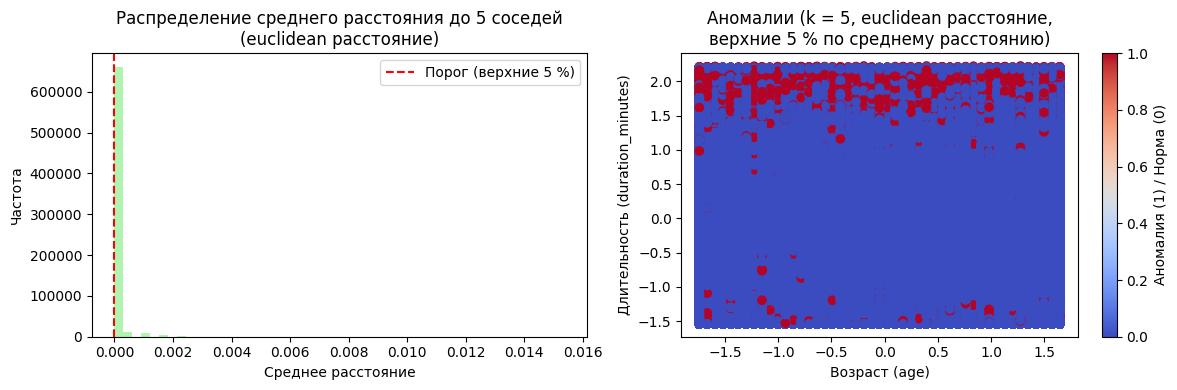


Анализ для k = 7
Статистика для k=7, метрика=euclidean:
  Среднее расстояние до 7 соседей: 0.0001 ± 0.0004
  Минимум/максимум: 0.0000 / 0.0167
  Порог аномальности (верхние 5 %): 0.0008
  Количество аномалий: 29603 (4.30 % от общего числа точек)


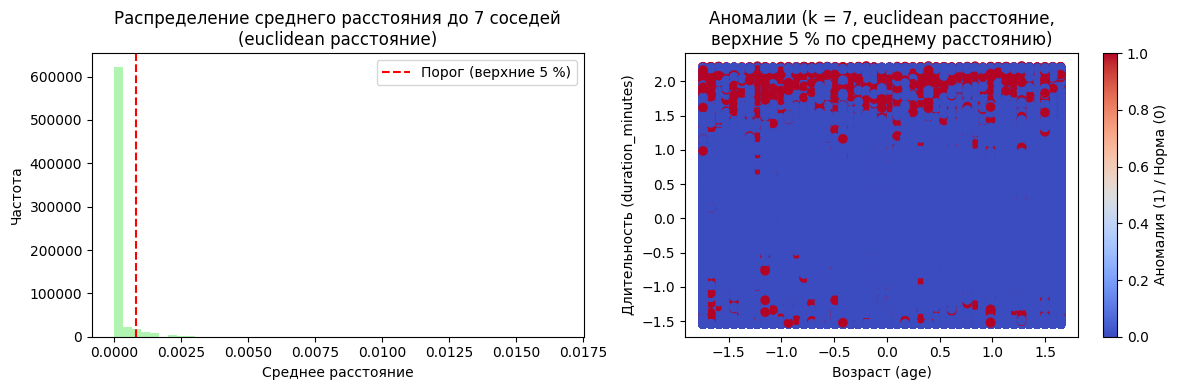


Анализ для k = 9
Статистика для k=9, метрика=euclidean:
  Среднее расстояние до 9 соседей: 0.0002 ± 0.0005
  Минимум/максимум: 0.0000 / 0.0180
  Порог аномальности (верхние 5 %): 0.0013
  Количество аномалий: 31312 (4.55 % от общего числа точек)


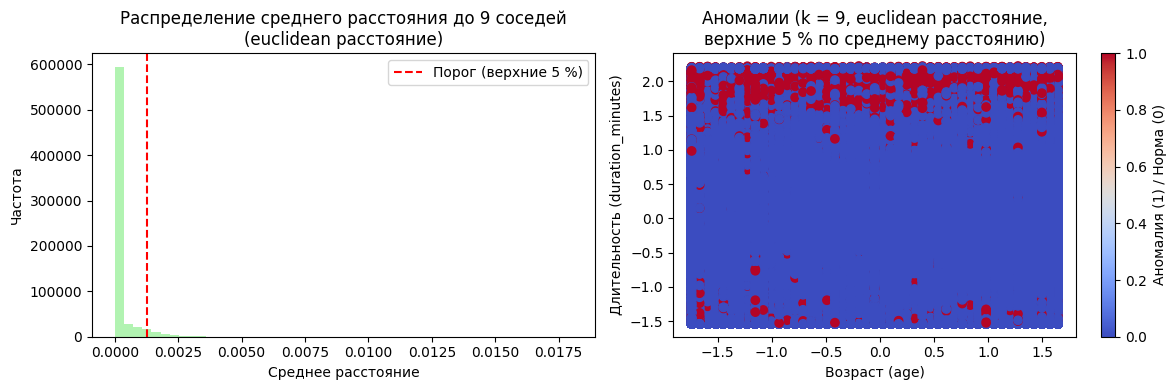


Анализ для k = 10
Статистика для k=10, метрика=euclidean:
  Среднее расстояние до 10 соседей: 0.0002 ± 0.0006
  Минимум/максимум: 0.0000 / 0.0185
  Порог аномальности (верхние 5 %): 0.0014
  Количество аномалий: 32619 (4.74 % от общего числа точек)


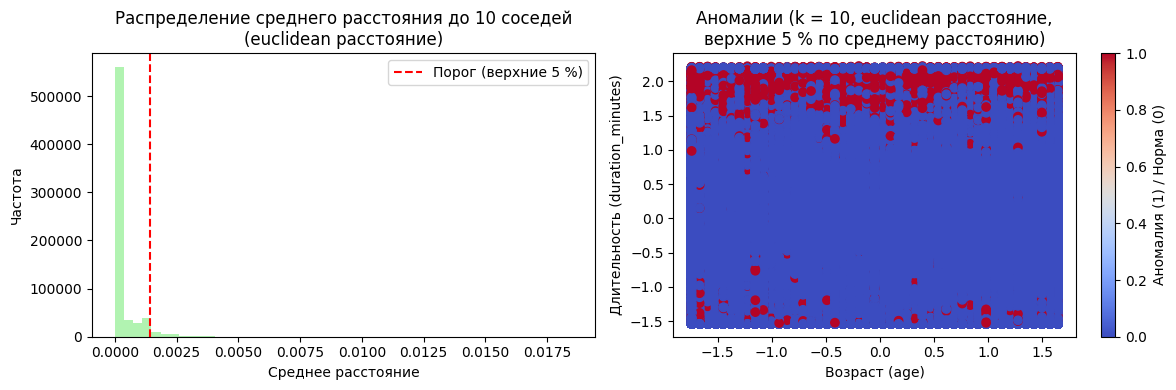


   Анализ с использованием MANHATTAN расстояний

Анализ для k = 5
Статистика для k=5, метрика=manhattan:
  Среднее расстояние до 5 соседей: 0.0000 ± 0.0002
  Минимум/максимум: 0.0000 / 0.0154
  Порог аномальности (верхние 5 %): 0.0000
  Количество аномалий: 25862 (3.76 % от общего числа точек)


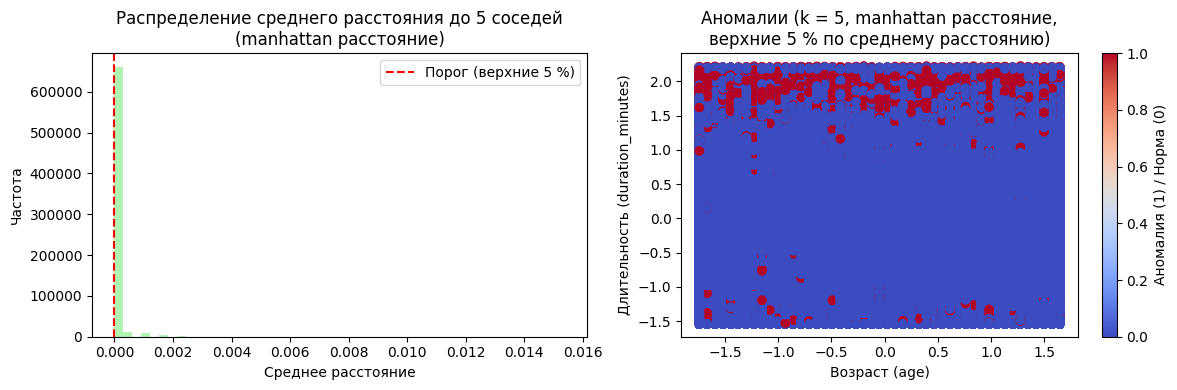


Анализ для k = 7
Статистика для k=7, метрика=manhattan:
  Среднее расстояние до 7 соседей: 0.0001 ± 0.0004
  Минимум/максимум: 0.0000 / 0.0167
  Порог аномальности (верхние 5 %): 0.0008
  Количество аномалий: 29603 (4.30 % от общего числа точек)


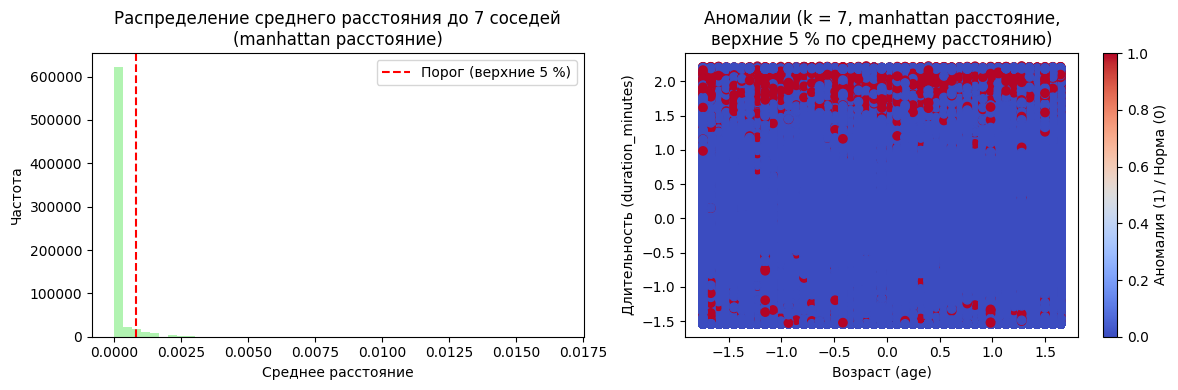


Анализ для k = 9
Статистика для k=9, метрика=manhattan:
  Среднее расстояние до 9 соседей: 0.0002 ± 0.0005
  Минимум/максимум: 0.0000 / 0.0180
  Порог аномальности (верхние 5 %): 0.0013
  Количество аномалий: 31312 (4.55 % от общего числа точек)


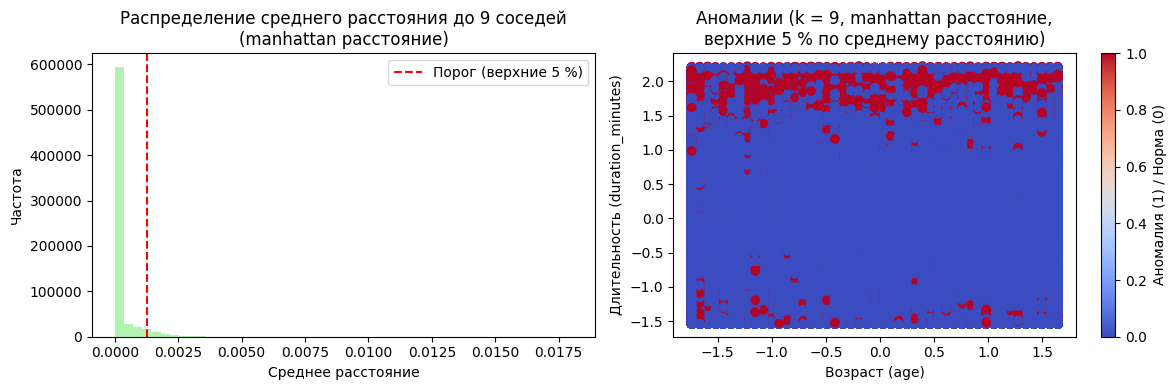


Анализ для k = 10
Статистика для k=10, метрика=manhattan:
  Среднее расстояние до 10 соседей: 0.0002 ± 0.0006
  Минимум/максимум: 0.0000 / 0.0185
  Порог аномальности (верхние 5 %): 0.0014
  Количество аномалий: 32619 (4.74 % от общего числа точек)


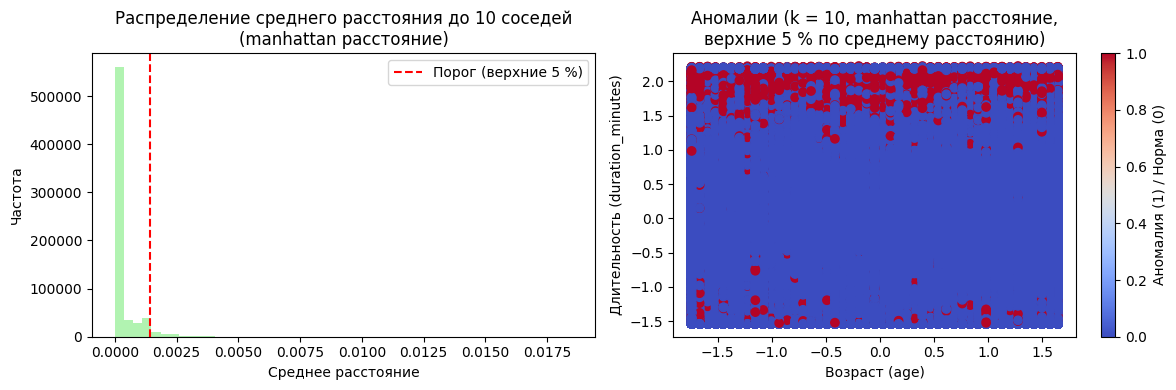

Анализ устойчивости метода при изменении k

EUCLIDEAN расстояние:
  k=5: 25862 аномалий
  k=7: 29603 аномалий
  k=9: 31312 аномалий
  k=10: 32619 аномалий
  Вывод: Метод чувствителен к выбору k - количество аномалий существенно меняется

MANHATTAN расстояние:
  k=5: 25862 аномалий
  k=7: 29603 аномалий
  k=9: 31312 аномалий
  k=10: 32619 аномалий
  Вывод: Метод чувствителен к выбору k - количество аномалий существенно меняется


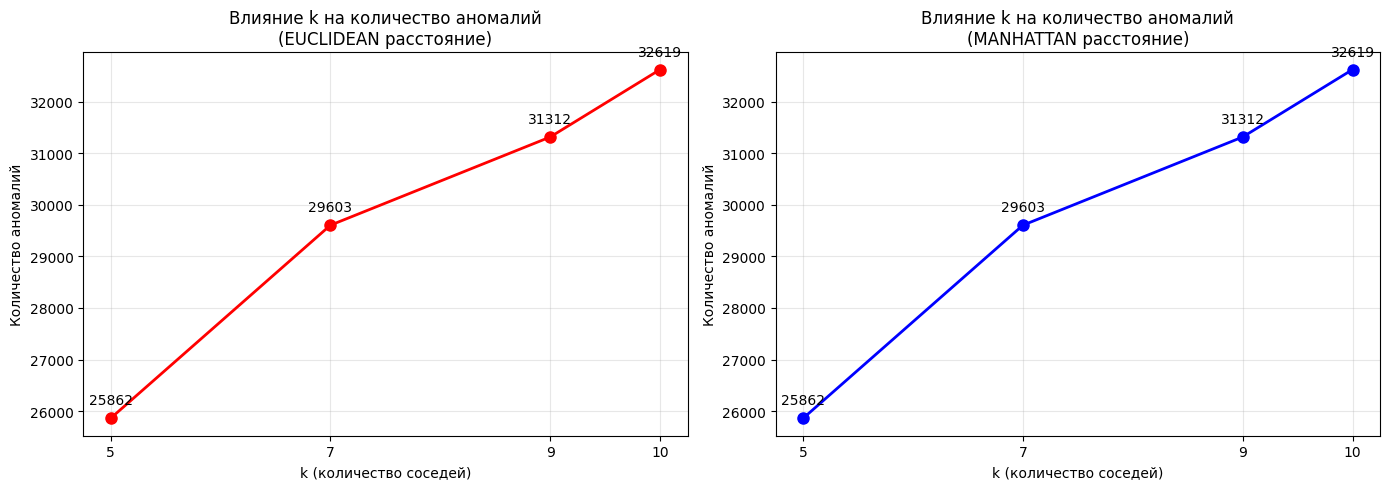

Сравнение результатов между метриками

--- Для k = 5 ---
Аномалии по Евклиду: 25862
Аномалии по Манхэттену: 25862
Общие аномалии: 25862
Только по Евклиду: 0
Только по Манхэттену: 0
Совпадение с Евклидом: 100.0%
Совпадение с Манхэттеном: 100.0%

--- Для k = 7 ---
Аномалии по Евклиду: 29603
Аномалии по Манхэттену: 29603
Общие аномалии: 29603
Только по Евклиду: 0
Только по Манхэттену: 0
Совпадение с Евклидом: 100.0%
Совпадение с Манхэттеном: 100.0%

--- Для k = 9 ---
Аномалии по Евклиду: 31312
Аномалии по Манхэттену: 31312
Общие аномалии: 31312
Только по Евклиду: 0
Только по Манхэттену: 0
Совпадение с Евклидом: 100.0%
Совпадение с Манхэттеном: 100.0%

--- Для k = 10 ---
Аномалии по Евклиду: 32619
Аномалии по Манхэттену: 32619
Общие аномалии: 32619
Только по Евклиду: 0
Только по Манхэттену: 0
Совпадение с Евклидом: 100.0%
Совпадение с Манхэттеном: 100.0%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

X = df[['age', 'duration_minutes']].values

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = [5, 7, 9, 10]
alpha = 0.05  # Верхние 5 % как аномалии
metrics = ['euclidean', 'manhattan']
#Евклидово расстояние - прямая линия между точками: sqr[(x₁-x₂)² + (y₁-y₂)²]
#Манхэттенское расстояние - сумма абсолютных разностей по осям: |x₁-x₂| + |y₁-y₂|
results = {}

for metric in metrics:
    print(f"\n   Анализ с использованием {metric.upper()} расстояний")
    for k in k_values:
        print(f"\nАнализ для k = {k}")

        # Инициализация и обучение
        nn = NearestNeighbors(n_neighbors=k, metric=metric)
        nn.fit(X_scaled)
        distances, indices = nn.kneighbors(X_scaled)  # расстояния до k ближ соседей для каждой точки

        # Среднее расстояние до k соседей
        D_avg = np.mean(distances, axis=1)
        # Определение порога аномальности (верхние alpha % значений среднего расстояния)
        threshold = np.percentile(D_avg, 100 * (1 - alpha))
        anomalies = D_avg > threshold

        # Сохранение результатов
        if metric not in results:
            results[metric] = {}
        results[metric][k] = {
            'D_avg': D_avg,
            'anomalies': anomalies,
            'threshold': threshold
        }

        print(f"Статистика для k={k}, метрика={metric}:")
        print(f"  Среднее расстояние до {k} соседей: {np.mean(D_avg):.4f} ± {np.std(D_avg):.4f}")
        print(f"  Минимум/максимум: {np.min(D_avg):.4f} / {np.max(D_avg):.4f}")
        print(f"  Порог аномальности (верхние {alpha*100:.0f} %): {threshold:.4f}")
        print(f"  Количество аномалий: {np.sum(anomalies)} ({np.sum(anomalies) / len(X) * 100:.2f} % от общего числа точек)")

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.hist(D_avg, bins=50, color='lightgreen', alpha=0.7)
        plt.axvline(threshold, color='red', linestyle='--', label=f'Порог (верхние {alpha*100:.0f} %)')
        plt.title(f'Распределение среднего расстояния до {k} соседей\n({metric} расстояние)')
        plt.xlabel('Среднее расстояние')
        plt.ylabel('Частота')
        plt.legend(loc='upper right')


        anomalies = results[metric][k]['anomalies']
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=anomalies.astype(int), cmap='coolwarm')
        plt.title(f'Аномалии (k = {k}, {metric} расстояние,\nверхние {alpha*100:.0f} % по среднему расстоянию)')
        plt.xlabel('Возраст (age)')
        plt.ylabel('Длительность (duration_minutes)')
        plt.colorbar(scatter, label='Аномалия (1) / Норма (0)')
        plt.tight_layout()
        plt.show()


print("Анализ устойчивости метода при изменении k")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(metrics):
    anomaly_counts = []
    k_list = []

    for k in k_values:
        count = np.sum(results[metric][k]['anomalies'])
        anomaly_counts.append(count)
        k_list.append(k)

    axes[idx].plot(k_list, anomaly_counts, 'o-', linewidth=2, markersize=8,
                   color='red' if metric == 'euclidean' else 'blue')
    axes[idx].set_xlabel('k (количество соседей)')
    axes[idx].set_ylabel('Количество аномалий')
    axes[idx].set_title(f'Влияние k на количество аномалий\n({metric.upper()} расстояние)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(k_list)

    # Добавим подписи значений
    for i, count in enumerate(anomaly_counts):
        axes[idx].annotate(str(count), (k_list[i], count),
                          textcoords="offset points", xytext=(0,10), ha='center')

    # Анализ устойчивости
    print(f"\n{metric.upper()} расстояние:")
    print(f"  k=5: {anomaly_counts[0]} аномалий")
    print(f"  k=7: {anomaly_counts[1]} аномалий")
    print(f"  k=9: {anomaly_counts[2]} аномалий")
    print(f"  k=10: {anomaly_counts[3]} аномалий")

    # Оценка устойчивости
    if len(set(anomaly_counts)) == 1:
        print(f"  Вывод: Метод очень устойчив - количество аномалий не меняется при изменении k")
    elif len(set(anomaly_counts)) <= 2:
        print(f"  Вывод: Метод достаточно устойчив - количество аномалий меняется незначительно")
    else:
        print(f"  Вывод: Метод чувствителен к выбору k - количество аномалий существенно меняется")

plt.tight_layout()
plt.show()



print("Сравнение результатов между метриками")
for k in k_values:
    print(f"\n--- Для k = {k} ---")
    # Получаем аномалии для обеих метрик
    anomalies_euclidean = results['euclidean'][k]['anomalies']
    anomalies_manhattan = results['manhattan'][k]['anomalies']

    # Количество точек, признанных аномалиями
    count_euclidean = np.sum(anomalies_euclidean)
    count_manhattan = np.sum(anomalies_manhattan)

    # Пересечение аномалий
    both_anomalies = np.logical_and(anomalies_euclidean, anomalies_manhattan)
    both_count = np.sum(both_anomalies)

    # Уникальные аномалии
    only_euclidean = np.sum(np.logical_and(anomalies_euclidean, ~anomalies_manhattan))
    only_manhattan = np.sum(np.logical_and(anomalies_manhattan, ~anomalies_euclidean))

    print(f"Аномалии по Евклиду: {count_euclidean}")
    print(f"Аномалии по Манхэттену: {count_manhattan}")
    print(f"Общие аномалии: {both_count}")
    print(f"Только по Евклиду: {only_euclidean}")
    print(f"Только по Манхэттену: {only_manhattan}")

    if both_count > 0:
        # Процент совпадения относительно каждой метрики
        overlap_percent_euclidean = (both_count / count_euclidean) * 100 if count_euclidean > 0 else 0
        overlap_percent_manhattan = (both_count / count_manhattan) * 100 if count_manhattan > 0 else 0
        print(f"Совпадение с Евклидом: {overlap_percent_euclidean:.1f}%")
        print(f"Совпадение с Манхэттеном: {overlap_percent_manhattan:.1f}%")